In [18]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from scipy.special import softmax
from scipy.stats import gumbel_r
from scipy.stats import norm
from scipy.special import logit

import utilities as utils

### Script parameters and variables

In [3]:
### operational parameters ###

savedir = "./Figures/"
savefigflag = False
savedataflag = True # save data produced by this notebook
loaddataflag = True # load data already produced by this notebook, instead of re-running analyses

beads_datadir = "./Data/beads/"
horses_datadir = "./Data/horses/"

# number of threads for parallelized analyses
N_threads = 22


### parameters governing analyses ###

# confidence interval of I(R;Y) for bootstrapping analyses
CI = (2.5, 97.5)
boot_iters = 1000 # number of bootstrap iterations

# number of beads to include in X, from current trial backward (bead-prediction experiment) for "fully-optimal" strategy
wsize = 7

# limit for the number of iterations for the IB algorithm
IB_iterlimit = 100000
N_b_ib = 1000 # number of beta points to sample for the standard IB algorithm
max_b_ib = 50 # maximum beta value to sample for the standard IB algorithm
N_b_softmax = 10000 # number of betastar points to sample for the softmax solution
max_b_softmax = 50 # maximum betastar value to sample for the softmax solution


### fixed parameters for the generative structure of the experiments ###

# generative parameters for the bead-prediction experiment
h_=0.99 # jar stay probability
p0_=0.8 # probability of drawing bead type 0 from jar 0
p1_=0.2 # probability of drawing bead type 0 from jar 1
P0 = np.array([[0.5, 0.5]]) # prior over jars for computing posterior probabilities over hidden markov process
H = np.ones((2,2)) - np.abs(np.eye(2)*-1 + h_) # transition matrix
E = np.vstack((np.array([[1,0]])*p0_ + np.array([[0,1]])*(1-p0_),np.array([[1,0]])*p1_ + np.array([[0,1]])*(1-p1_))) # emission matrix

# generative parameters for the horse prediction experiments
paramdict = {
    'lowWS': {
        'weakLLR': 0.45,
        'WSratio': 1.3,
        'p1': 0.06
    },
    'midWS': {
        'weakLLR': 0.2,
        'WSratio': 2.5,
        'p1': 0.08
    },
    'highWS': {
        'weakLLR': 0.18,
        'WSratio': 6.3,
        'p1': 0.02
    }
}

# p(Y) for both tasks
p_Y = np.array([[0.5, 0.5]])


### plotting parameters ###

# teal color map
start_color = "#ffffff"  
end_color = "#136666"    
cmap_t = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [start_color, end_color])

# red color map
cmap_r = matplotlib.colormaps.get_cmap('Reds')

optcolor = "#298C8C"
heurcolor = "#A00000"
nonecolor = 'orange'
fullparamcolor = plt.get_cmap('tab10')(4)


### helper functions ###

def savefig(fig, name, ftype="svg", savefigflag=savefigflag, savedir=savedir):
    if savefigflag:
        fig.savefig(savedir + name + "." + ftype, bbox_inches="tight", dpi=300)

def format_axis(ax):
    ax.tick_params(axis='x', labelsize=5, width=0.5, length=2)
    ax.tick_params(axis='y', labelsize=5, width=0.5, length=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

def get_color(index,values,vmin,vmax):
    return np.clip(1-(values[index]-vmin)/(vmax-vmin),0,1)

### Import some preprocessed data

In [4]:
# bead prediction trial sequence
beads_trial_seq = pd.read_csv(beads_datadir + "trial_sequence.csv")
jars_emp_raw = beads_trial_seq['jar'].to_numpy()
beads_emp_raw = beads_trial_seq['bead'].to_numpy()
beads_emp, jars_emp = utils.getXY_beads(beads_emp_raw, jars_emp_raw, wsize)

# horse prediction experiment trial sets (emp = empirical data)
lowWS_trial_set = pd.read_csv(horses_datadir + "lowWS/trial_set.csv")
shapes_low_emp = utils.split_to_four_digits(lowWS_trial_set['observation_encoding'].to_numpy())
horses_low_emp = lowWS_trial_set['latent_state'].to_numpy()

midWS_trial_set = pd.read_csv(horses_datadir + "midWS_learning/trial_set.csv")
shapes_mid_emp = utils.split_to_four_digits(midWS_trial_set['observation_encoding'].to_numpy())
horses_mid_emp = midWS_trial_set['latent_state'].to_numpy()

highWS_trial_set = pd.read_csv(horses_datadir + "highWS/trial_set.csv")
shapes_high_emp = utils.split_to_four_digits(highWS_trial_set['observation_encoding'].to_numpy())
horses_high_emp = highWS_trial_set['latent_state'].to_numpy()

shapes_emp_dict = {
    'lowWS': shapes_low_emp,
    'midWS': shapes_mid_emp,
    'highWS': shapes_high_emp
}

horses_emp_dict = {
    'lowWS': horses_low_emp,
    'midWS': horses_mid_emp,
    'highWS': horses_high_emp
}

## Figure A1

In [5]:
# get IB bound (IB-optimal for true p(X,Y)) on the experimental trial set
shapes_Xset = utils.get_shapes_Xset()
p_XgY = utils.P_shapecomb_g_horse(shapes_Xset,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
emp_bound = utils.get_IB_bound_emp(shapes_high_emp,shapes_Xset,horses_high_emp,p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads)

# get IB curve for softmax solution on the experimental trial set
p_YgX_emp = utils.P_horse_g_shapecomb(shapes_high_emp,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'],p_Y=p_Y)
emp_softmax_curve = utils.get_softmax_IB_curve_emp(shapes_high_emp,horses_high_emp,p_YgX_emp,N_b=N_b_softmax,max_b=max_b_softmax)

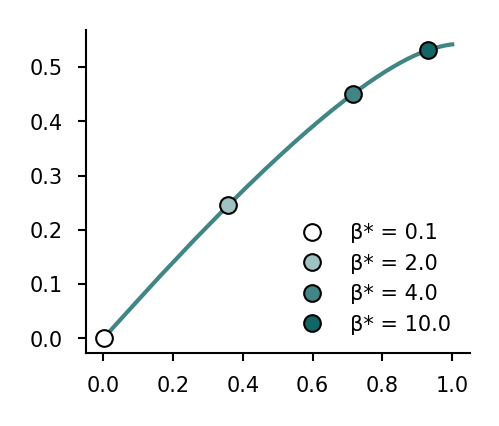

In [7]:
betastars = np.array([0.1, 2, 4, 10])

fig, ax = plt.subplots(figsize=(1.65,1.4), dpi=300)

ibbound, = ax.plot(emp_bound['I_XR'], emp_bound['I_RY'], label='IB bound', color=cmap_t(0.8), linewidth=1)

legend_handles = []
legend_labels = []
for ii, bb in enumerate(betastars):
    softmax_soln = utils.get_softmax_IB_emp(bb,shapes_high_emp,horses_high_emp,p_YgX_emp,return_dict=True)
    if ii == 0:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,1,5)),markeredgecolor='k',markersize=4,markeredgewidth=0.5)
    else:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,0,5)),markeredgecolor='k',markersize=4,markeredgewidth=0.5)
    legend_handles.append(soln,)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='lower right')


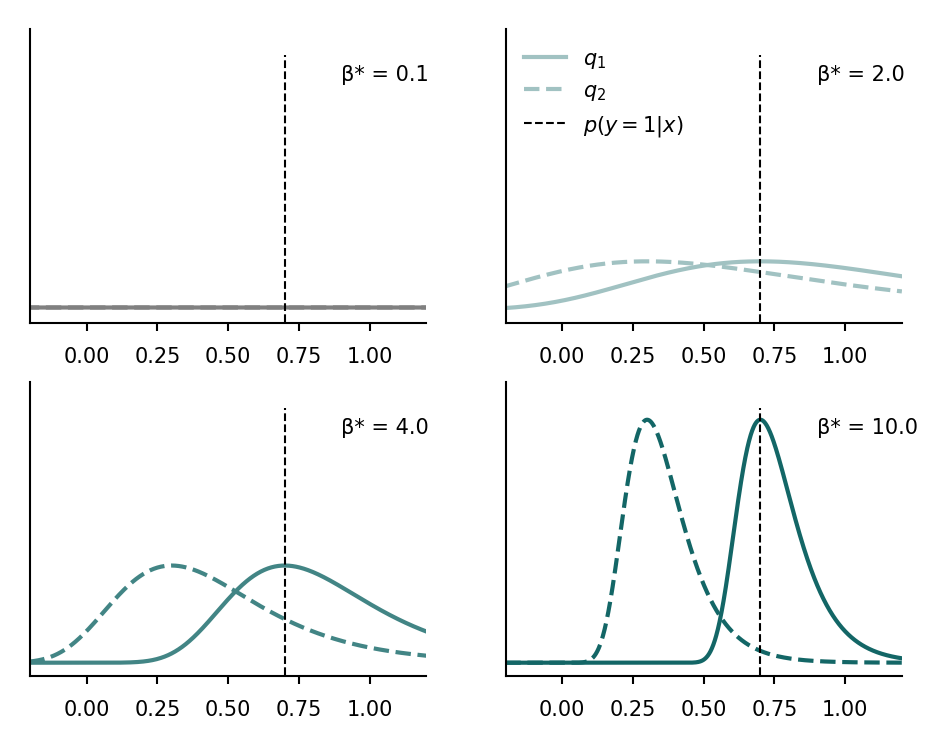

In [15]:
fig, ax = plt.subplots(2,2,figsize=(3.75,2.8), dpi=300)

x = np.arange(-100,100,0.01)
p1 = 0.3
p2 = 0.7
betastars = np.array([0.1, 2, 4, 10])

ymin = np.inf
ymax = -np.inf
for ii, bb in enumerate(betastars):
    r,c = divmod(ii,2)
    if ii == 0:
        line2, = ax[r,c].plot(x/bb+p2,gumbel_r.pdf(x)*bb,c='gray',linewidth=1,label=r'$q_1$')
        line1, = ax[r,c].plot(x/bb+p1,gumbel_r.pdf(x)*bb,c='gray',linewidth=1,linestyle='--',label=r'$q_2$')
    else:
        line2, = ax[r,c].plot(x/bb+p2,gumbel_r.pdf(x)*bb,c=cmap_t(1-get_color(ii,betastars,0,5)),linewidth=1,label=r'$q_1$')
        line1, = ax[r,c].plot(x/bb+p1,gumbel_r.pdf(x)*bb,c=cmap_t(1-get_color(ii,betastars,0,5)),linewidth=1,linestyle='--',label=r'$q_2$')
    ylim = ax[r,c].get_ylim()
    ymin = min(ymin, ylim[0])
    ymax = max(ymax, ylim[1])

for ii, bb in enumerate(betastars):
    r,c = divmod(ii,2)
    ax[r,c].set_xlim([p1-0.5,p2+0.5])
    vline = ax[r,c].vlines(p2, ymin, ymax, colors='black', linestyles='--', linewidth=0.5,label=r'$p(y=1|x)$')
    if ii == 1:
        ax[r,c].legend(fontsize=5, frameon=False, loc='upper left')
    # add text giving beta value
    ax[r,c].text(p2+0.2, ymax*0.9, f'β* = {bb}', fontsize=5)
    ax[r,c].set_ylim(np.array([ymin, ymax])*1.1)
    ax[r,c].tick_params(axis='x', labelsize=5, width=0.5, length=2)
    format_axis(ax[r,c])
    ax[r,c].set_xlabel('', fontsize=5)
    ax[r,c].set_ylabel('', fontsize=5)
    ax[r,c].set_yticklabels([])
    ax[r,c].tick_params(axis='y', width=0.5, length=0)

(-0.04995006234442733, 1.0499500623444273)

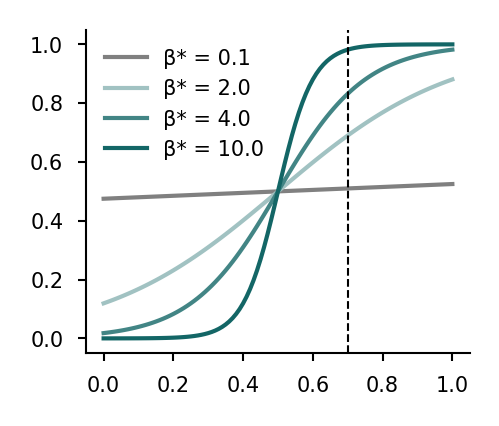

In [16]:
betastars = np.array([0.1, 2, 4, 10])

p = np.arange(0,1.01,0.01).reshape(-1,1)

legend_handles = []  
legend_labels = []

fig, ax = plt.subplots(figsize=(1.65,1.4), dpi=300)

for ii, bb in enumerate(betastars):
    curve = softmax(bb*np.concatenate((p,1-p),axis=1),axis=1)
    if ii == 0:
        line, = ax.plot(p, curve[:, 0],c='gray', label=f'β = {bb}',linewidth=1)
    else:
        line, = ax.plot(p,curve[:,0],c=cmap_t(1-get_color(ii,betastars,0,5)), label=f'β = {bb}',linewidth=1)
    legend_handles.append(line)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='best')

ylim = ax.get_ylim()
ax.vlines(p2, ylim[0], ylim[1], colors='black', linestyles='--', linewidth=0.5)
ax.set_ylim(ylim)

## Figure A2

In [19]:
shapes_Xset = utils.get_shapes_Xset()
p_XgY_mid = utils.P_shapecomb_g_horse(shapes_Xset,paramdict['midWS']['weakLLR'],paramdict['midWS']['WSratio'],paramdict['midWS']['p1'])
p_YgX_mid = utils.P_horse_g_shapecomb(shapes_Xset,paramdict['midWS']['weakLLR'],paramdict['midWS']['WSratio'],paramdict['midWS']['p1'],p_Y=p_Y)

# softmax solution (posterior probabilities transformed by the softmax function)
posterior_softmax_curve = utils.get_softmax_IB_curve(p_XgY_mid,p_Y,N_b=N_b_softmax,max_b=max_b_softmax)

# posterior probabilities with cumulative normal noise (with scale parameter chosen to approximate the slope of the softmax function at p=0.5)
posterior_normal = lambda betastar : norm.cdf(p_YgX_mid,loc=0.5,scale=(4/np.sqrt(2*np.pi))/betastar)
betastars = np.linspace(max_b_softmax/N_b_softmax,max_b_softmax,N_b_softmax)
posterior_normal_curve = utils.get_general_IB_curve(betastars,p_XgY_mid,p_Y,posterior_normal)

# log-posterior odds with softmax noise
lpo_softmax = lambda betastar : softmax(logit(p_YgX_mid)*betastar,axis=1)
lpo_softmax_curve = utils.get_general_IB_curve(betastars,p_XgY_mid,p_Y,lpo_softmax)

# log-posterior odds with normal noise
lpo_normal = lambda betastar : norm.cdf(logit(p_YgX_mid),loc=0,scale=(4/np.sqrt(2*np.pi))/betastar)
lpo_normal_curve = utils.get_general_IB_curve(betastars,p_XgY_mid,p_Y,lpo_normal)

/workspaces/human-inference-IB/utilities.py:96: RuntimeWarning: divide by zero encountered in log2
  return np.sum(p_RgX*p_X*np.log2(p_RgX/p_R))
/workspaces/human-inference-IB/utilities.py:96: RuntimeWarning: invalid value encountered in multiply
  return np.sum(p_RgX*p_X*np.log2(p_RgX/p_R))


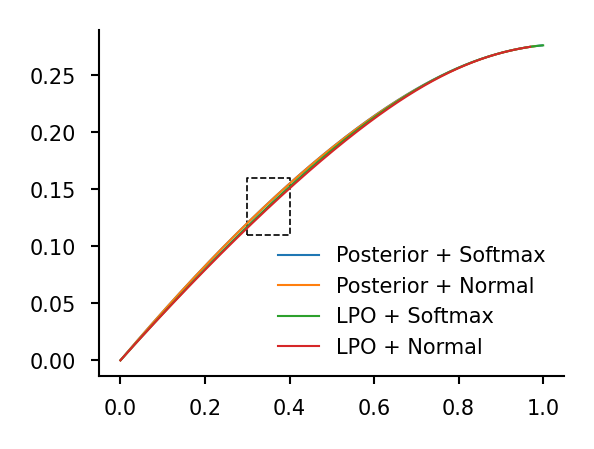

In [ ]:
fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

# draw box around x= [0.3,0.4] and y=[0.11,0.16]
ax.plot([0.3,0.4,0.4,0.3,0.3],[0.11,0.11,0.16,0.16,0.11],'k--',linewidth=0.4)

ax.plot(posterior_softmax_curve['I_XR'],posterior_softmax_curve['I_RY'],label='Posterior + Softmax',linewidth=0.5)
ax.plot(posterior_normal_curve['I_XR'],posterior_normal_curve['I_RY'],label='Posterior + Normal',linewidth=0.5)
ax.plot(lpo_softmax_curve['I_XR'],lpo_softmax_curve['I_RY'],label='LPO + Softmax',linewidth=0.5)
ax.plot(lpo_normal_curve['I_XR'],lpo_normal_curve['I_RY'],label='LPO + Normal',linewidth=0.5)

format_axis(ax)
ax.legend(fontsize=5, frameon=False, loc='best')

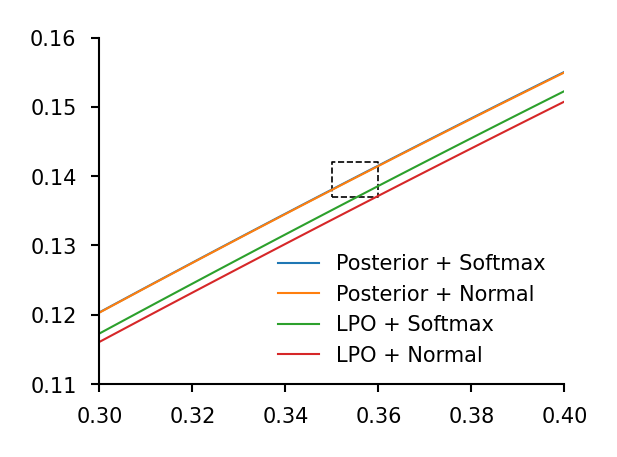

In [ ]:
fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

# draw box around x= [0.35,0.36] and y=[0.137,0.142]
ax.plot([0.35,0.36,0.36,0.35,0.35],[0.137,0.137,0.142,0.142,0.137],'k--',linewidth=0.4)

ax.plot(posterior_softmax_curve['I_XR'],posterior_softmax_curve['I_RY'],label='Posterior + Softmax',linewidth=0.5)
ax.plot(posterior_normal_curve['I_XR'],posterior_normal_curve['I_RY'],label='Posterior + Normal',linewidth=0.5)
ax.plot(lpo_softmax_curve['I_XR'],lpo_softmax_curve['I_RY'],label='LPO + Softmax',linewidth=0.5)
ax.plot(lpo_normal_curve['I_XR'],lpo_normal_curve['I_RY'],label='LPO + Normal',linewidth=0.5)

ax.set_xlim([0.3,0.4])
ax.set_ylim([0.11,0.16])
format_axis(ax)
# ax.legend(fontsize=5, frameon=False, loc='best')

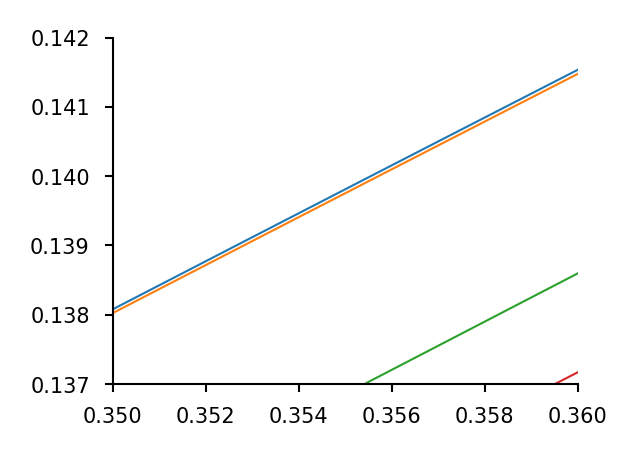

In [23]:
fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

ax.plot(posterior_softmax_curve['I_XR'],posterior_softmax_curve['I_RY'],label='Posterior + Softmax',linewidth=0.5)
ax.plot(posterior_normal_curve['I_XR'],posterior_normal_curve['I_RY'],label='Posterior + Normal',linewidth=0.5)
ax.plot(lpo_softmax_curve['I_XR'],lpo_softmax_curve['I_RY'],label='LPO + Softmax',linewidth=0.5)
ax.plot(lpo_normal_curve['I_XR'],lpo_normal_curve['I_RY'],label='LPO + Normal',linewidth=0.5)

ax.set_xlim([0.35,0.36])
ax.set_ylim([0.137,0.142])
format_axis(ax)

## Figure A3

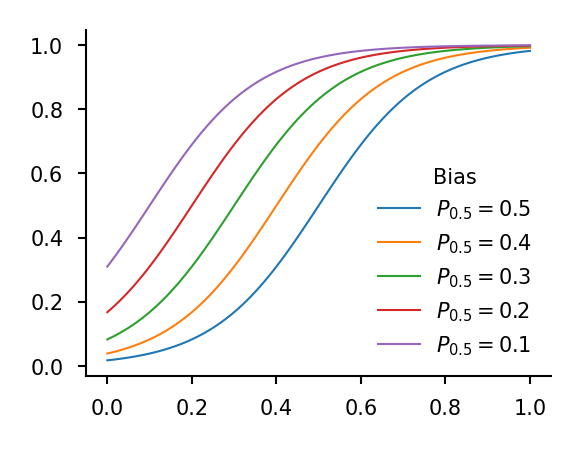

In [25]:
biases = [0, 0.1, 0.2, 0.3, 0.4]

p = np.arange(0,1.01,0.01).reshape(-1,1)
p_YgX = np.concatenate((p,1-p),axis=1)
betastar = 4
P_RgX = lambda bias : np.exp(betastar*(p_YgX+np.array([bias,-bias]))) / np.sum(np.exp(betastar*(p_YgX+np.array([bias,-bias]))),axis=1,keepdims=True)

cmap = plt.colormaps.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

for ii, bias in enumerate(biases):
    p_RgX_biased = P_RgX(bias)
    P05 = 0.5 - bias
    ax.plot(p_YgX[:,0], p_RgX_biased[:,0], c=cmap(ii), label=rf'$P_{{0.5}}={P05:.1f}$', linewidth=0.5)

format_axis(ax)
ax.legend(fontsize=5, title='Bias', title_fontsize=5, frameon=False, loc='best')

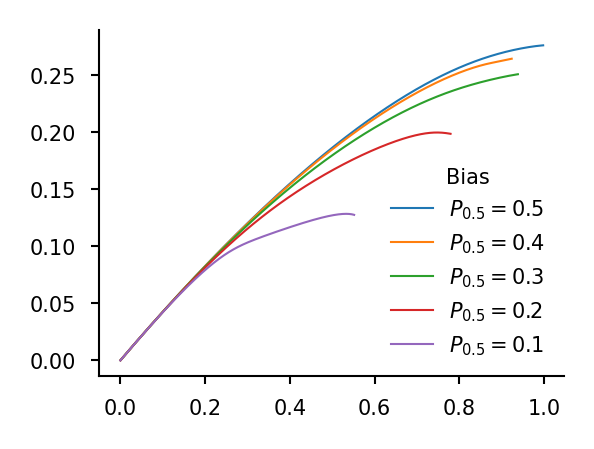

In [ ]:
shapes_Xset = utils.get_shapes_Xset()
p_XgY_mid = utils.P_shapecomb_g_horse(shapes_Xset,paramdict['midWS']['weakLLR'],paramdict['midWS']['WSratio'],paramdict['midWS']['p1'])
p_YgX_mid = utils.P_horse_g_shapecomb(shapes_Xset,paramdict['midWS']['weakLLR'],paramdict['midWS']['WSratio'],paramdict['midWS']['p1'],p_Y=p_Y)
P_RgX = lambda bias, betastar: np.exp(betastar*(p_YgX_mid+np.array([bias,-bias]))) / np.sum(np.exp(betastar*(p_YgX_mid+np.array([bias,-bias]))),axis=1,keepdims=True)

betastars = np.linspace(max_b_softmax/N_b_softmax,max_b_softmax,N_b_softmax)

cmap = plt.colormaps.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

for ii, bias in enumerate(biases):
    P_RgX_ = lambda betastar: P_RgX(bias, betastar)
    biased_softmax_curve = utils.get_general_IB_curve(betastars,p_XgY_mid,p_Y,P_RgX_)
    P05 = 0.5 - bias
    ax.plot(biased_softmax_curve['I_XR'], biased_softmax_curve['I_RY'], c=cmap(ii), label=rf'$P_{{0.5}}={P05:.1f}$', linewidth=0.5)
ax.legend(fontsize=5, title='Bias', title_fontsize=5, frameon=False, loc='best')
format_axis(ax)

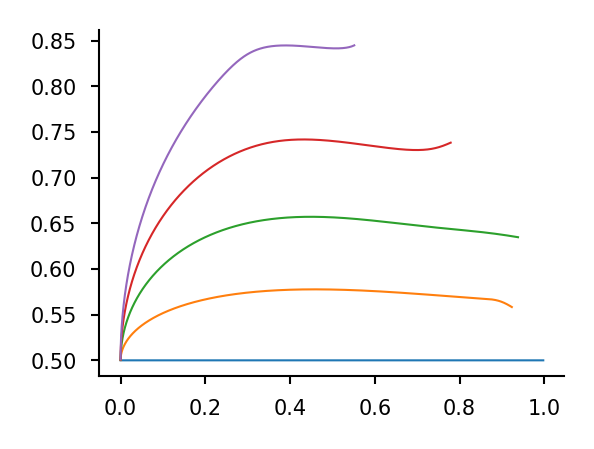

In [29]:
fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)
for ii, bias in enumerate(biases):
    P_RgX_ = lambda betastar: P_RgX(bias, betastar)
    Ixr_biased = []
    p_R0_biased = []
    for betastar in betastars:
        p_RgX = P_RgX_(betastar)
        Ixr_biased.append(utils.compute_I_XR(p_RgX, p_XgY_mid, p_Y))
        p_R0_biased.append(np.sum(p_RgX * np.sum(p_XgY_mid * p_Y,axis=1,keepdims=True),axis=0)[0])
    ax.plot(Ixr_biased, p_R0_biased, c=cmap(ii), label=rf'$P_{{0.5}}={P05:.1f}$', linewidth=0.5)
format_axis(ax)

## Figure A4

In [30]:
alldata_beads = pd.read_csv(beads_datadir + "all-sj-analysis-data.csv")

alldata_dict = {
    'lowWS': pd.read_csv(horses_datadir + "lowWS/all-sj-analysis-data.csv"),
    'midWS': pd.read_csv(horses_datadir + "midWS_learning/midWS_all-sj-analysis-data.csv"),
    'highWS': pd.read_csv(horses_datadir + "highWS/all-sj-analysis-data.csv")
}

In [ ]:
p_YgX_emp = utils.P_jar_g_beads(beads_emp, E,H,p_Y)
emp_softmax_curve_beads = utils.get_softmax_IB_curve_emp(beads_emp,jars_emp,p_YgX_emp,N_b=N_b_softmax,max_b=max_b_softmax)

conds = (alldata_beads['Ixr'] >= 0.05) & (alldata_beads['run']==2)

fig, ax = plt.subplots(figsize=(2.5, 2), dpi=300)

ib_theory, = ax.plot(emp_softmax_curve_beads['I_XR'], emp_softmax_curve_beads['betastar'], 'k', alpha=1, linewidth=0.8, label='Full bound theory')
ax.scatter(alldata_beads.loc[conds,'Ixr'],alldata_beads.loc[conds,'opt_betastar'],c=windf.loc[conds,'rel_entropy_7'],alpha=0.7,s=12,edgecolor='k',linewidth=0.3,cmap='viridis')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('$D_{KL}[p(r|x)_{subject}||p(r|x)_{model}]$', fontsize=6)
cbar.ax.tick_params(labelsize=5, width=0.5, length=2)
ax.set_ylim(-0.5,9)